
# Лабораторная работа №2. Выделение контуров. 

## Цель  работы:
Изучение  и  экспериментальное  исследование  методов выделения контуров  на изображениях с помощью линейной  обработки “окном”; получение навыков работы с автоматизированной  системой обработки изображений.

## Выполнил:
Богачев Матвей 6511 

В настоящей лабораторной работе рассматривается метод локальной  обработки изображений



In [680]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
from PIL import Image
import os

In [681]:
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['image.cmap'] = 'gray'

In [682]:

def load_image(image_path):
    """Загрузка изображения и преобразование в массив numpy"""
    try:
        img = Image.open(image_path)
        img_array = np.array(img.convert('L'))  # Преобразуем к float32 для работы с отрицательными значениями
        print(f"Размер загруженного изображения: {img_array.shape}")
        return img_array
    except Exception as e:
        print(f"Ошибка загрузки изображения: {e}")
        return None

In [683]:
def create_binary_image(gradient, threshold_ratio=0.3):
    threshold = threshold_ratio * gradient.max()
    binary = np.where(gradient > threshold, 255, 0)
    return binary.astype(np.uint8)

Размер загруженного изображения: (512, 512)
Диапазон значений: [12.0, 215.0]


Text(0, 0.5, 'Частота')

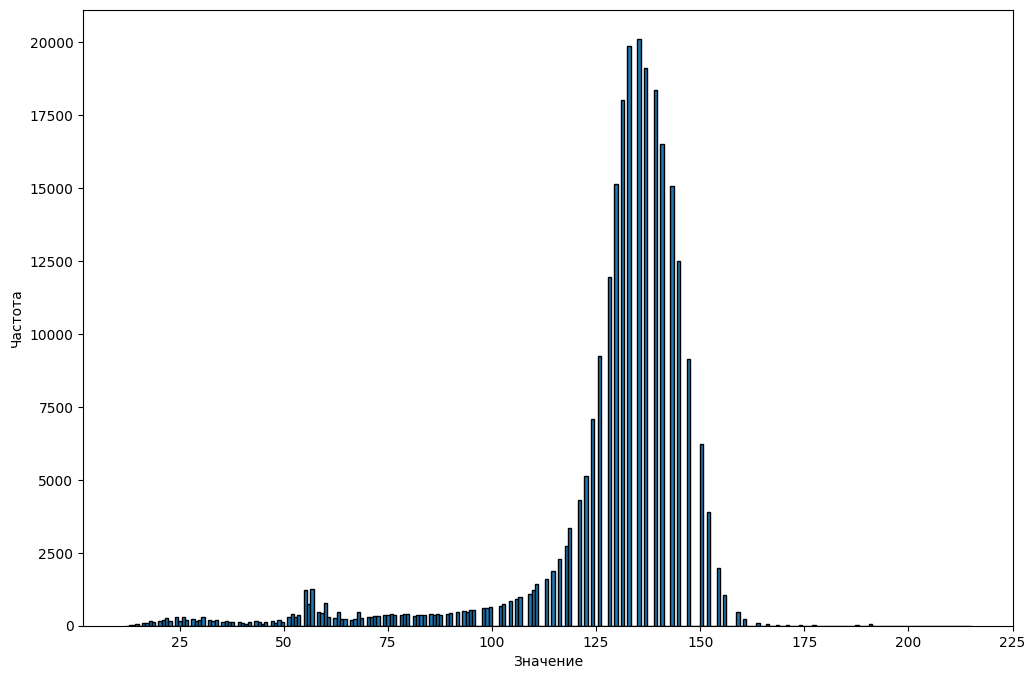

In [684]:
image_path = "data/01_apc.tif"

for_neg = 128

original_image = load_image(image_path)
print(f"Диапазон значений: [{original_image.min():.1f}, {original_image.max():.1f}]")

plt.hist(original_image.ravel(),bins= 256,edgecolor='black', rwidth=1)
plt.xlabel('Значение')
plt.ylabel('Частота')


# 1. Метод простого градиента

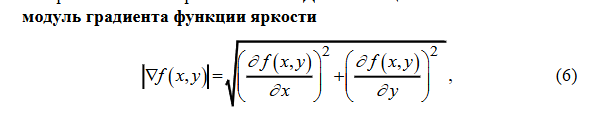

In [685]:
def simple_gradient_method(image):
    """Метод простого градиента"""
    # Преобразуем к типу с отрицательными значениями
    image_float = image.astype(np.float32)
    
    # Маски для частных производных
    # Производная по x (горизонтальное направление)
    kernel_x = np.array([[-1, 1]], dtype=np.float32)
    # Производная по y (вертикальное направление)  
    kernel_y = np.array([[-1], [1]], dtype=np.float32)

    partial_x = convolve2d(image_float, kernel_x, mode='same', boundary='symm')
    partial_y = convolve2d(image_float, kernel_y, mode='same', boundary='symm')
    
    # Оценка градиента (модуль градиента)
    gradient_magnitude = np.sqrt(partial_x**2 + partial_y**2)
    
    return partial_x, partial_y, gradient_magnitude


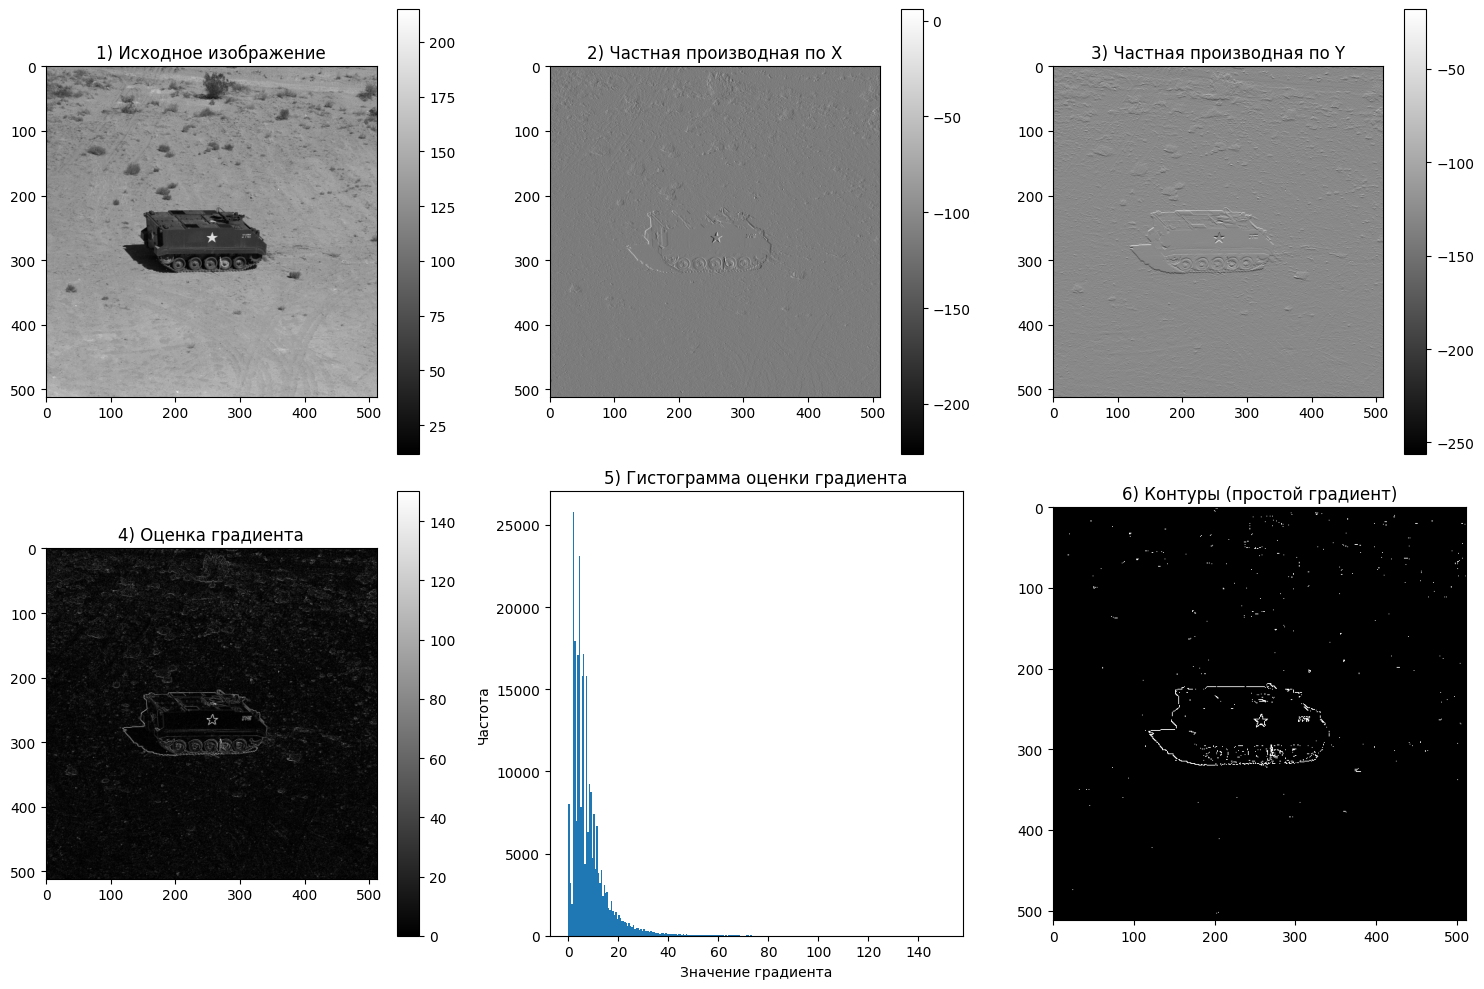

In [732]:
partial_x, partial_y, gradient_mag = simple_gradient_method(original_image)

# Визуализация результатов
plt.figure(figsize=(15, 10))
for_neg_x = partial_x.min()
for_neg_y = partial_y.min()
# 1) Исходное изображение
plt.subplot(2, 3, 1)
plt.imshow(original_image, cmap='gray')
plt.title('1) Исходное изображение')
plt.colorbar()

# 2) Частная производная по X
plt.subplot(2, 3, 2)
plt.imshow(partial_x + for_neg_x, cmap='gray')  # Добавляем 128 для отображения отрицательных значений
plt.title('2) Частная производная по X')
plt.colorbar()

# 3) Частная производная по Y  
plt.subplot(2, 3, 3)
plt.imshow(partial_y + for_neg_y, cmap='gray')
plt.title('3) Частная производная по Y')
plt.colorbar()

# 4) Оценка градиента
plt.subplot(2, 3, 4)
plt.imshow(gradient_mag, cmap='gray')
plt.title('4) Оценка градиента')
plt.colorbar()

# 5) Гистограмма оценки градиента
plt.subplot(2, 3, 5)
plt.hist(gradient_mag.flatten(), bins=256)
plt.title('5) Гистограмма оценки градиента')
plt.xlabel('Значение градиента')
plt.ylabel('Частота')

# 6) Контуры (бинарное изображение)
binary_contours = create_binary_image(gradient_mag, 0.32)
plt.subplot(2, 3, 6)
plt.imshow(binary_contours, cmap='gray')
plt.title('6) Контуры (простой градиент)')

plt.tight_layout()
plt.show()


# 2. Метод аппроксимации лапласиана (маски (20))

Оператор Лапласа:
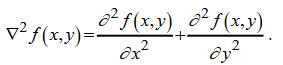

маска (20):
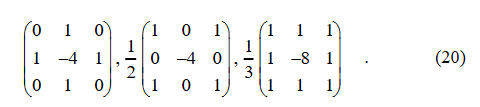


In [687]:
def create_binary_image_laplac(laplacian, threshold_ratio=0.3):
    """Создаёт бинарную карту контуров по нулевым переходам лапласиана."""
    lap = laplacian.astype(np.float32)
    sigma = np.std(lap)
    thresh = threshold_ratio * sigma

    pos = lap >  thresh
    neg = lap < -thresh

    # ядро 3x3 без центра
    kernel = np.array([[1,1,1],
                       [1,0,1],
                       [1,1,1]], dtype=np.uint8)
    
    pos_neigh = convolve2d(pos.astype(np.uint8), kernel, mode='same', boundary='symm')
    neg_neigh = convolve2d(neg.astype(np.uint8), kernel, mode='same', boundary='symm')

    # контуры = есть сосед с противоположным знаком
    zero_cross = (pos & (neg_neigh > 0)) | (neg & (pos_neigh > 0))
    return (zero_cross * 255).astype(np.uint8)

In [688]:
def laplacian_approximation_method(image):
    """Метод аппроксимации лапласиана (маска 20)"""
    img = image.astype(np.float32)
    laplacian_kernel = np.array([[0, 1, 0],
                                 [1, -4, 1],
                                 [0, 1, 0]], dtype=np.float32)

    laplacian = convolve2d(img, laplacian_kernel, mode='same', boundary='symm')
    return laplacian


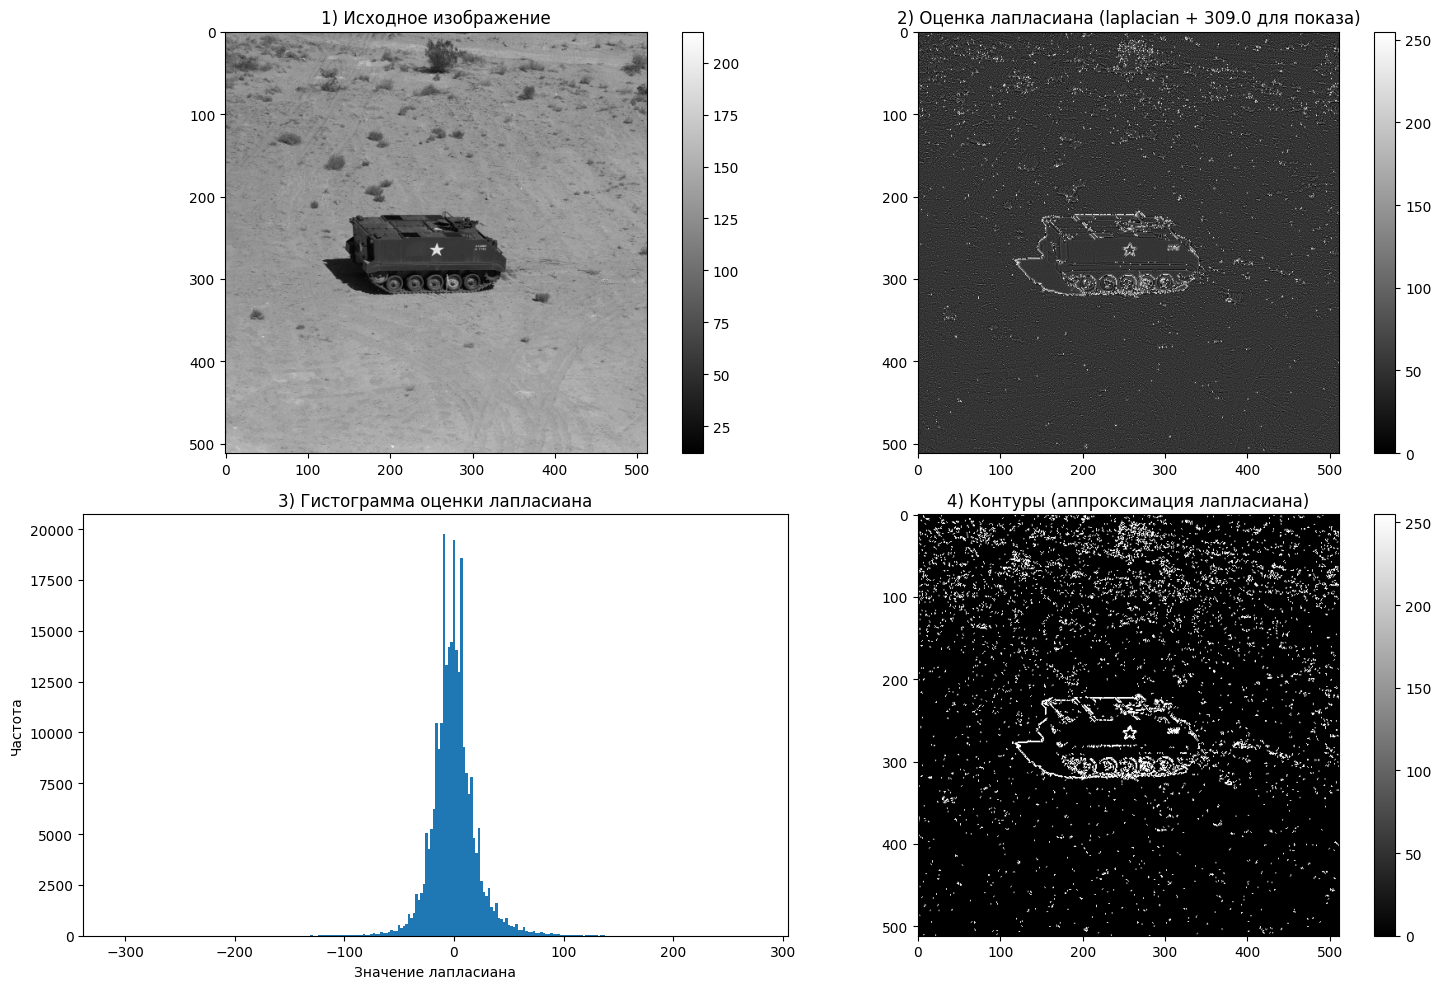

In [726]:
laplacian = laplacian_approximation_method(original_image)

for_neg = (-1* laplacian.min())

# Получаем бинарные контуры (zero-crossings)
zero_crossings = create_binary_image_laplac(laplacian, 1.6)
# Визуализация 
plt.figure(figsize=(15, 10))

# 1) Исходное изображение
plt.subplot(2, 2, 1)
plt.imshow(original_image, cmap='gray')
plt.title('1) Исходное изображение')
plt.colorbar()

# 2) Оценка лапласиана
plt.subplot(2, 2, 2)

plt.imshow((laplacian + for_neg).astype(np.uint8), cmap='gray')
plt.title(f'2) Оценка лапласиана (laplacian + {for_neg} для показа)')
plt.colorbar()

# 3) Гистограмма оценки лапласиана
plt.subplot(2, 2, 3)
plt.hist(laplacian.flatten(), bins=256, rwidth=1)
plt.title('3) Гистограмма оценки лапласиана')
plt.xlabel('Значение лапласиана')
plt.ylabel('Частота')

# 4) Контуры (бинарное изображение)
plt.subplot(2, 2, 4)
plt.imshow(zero_crossings, cmap='gray')
plt.title('4) Контуры (аппроксимация лапласиана)')
plt.colorbar()

plt.tight_layout()
plt.show()

# 3. Метод оператора Прюитт (маски (25)
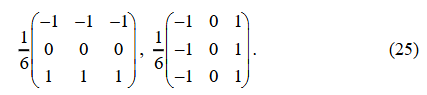

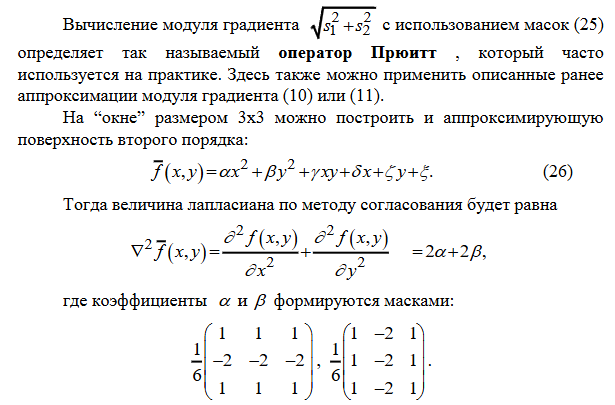

In [690]:
def prewitt_operator_method(image):
    """Метод оператора Прюитта (маски 25)"""
    image_float = image.astype(np.float32)
    
    # Маски Прюитта для горизонтальной и вертикальной производных
    kernel_x = np.array([[-1, 0, 1],
                         [-1, 0, 1],
                         [-1, 0, 1]], dtype=np.float32)
    
    kernel_y = np.array([[-1, -1, -1],
                         [0, 0, 0], 
                         [1, 1, 1]], dtype=np.float32)
    
    # Вычисляем частные производные
    partial_x = convolve2d(image_float, kernel_x, mode='same', boundary='symm')
    partial_y = convolve2d(image_float, kernel_y, mode='same', boundary='symm')
    
    # Оценка градиента
    gradient_magnitude = np.sqrt(partial_x**2 + partial_y**2)
    
    return partial_x, partial_y, gradient_magnitude


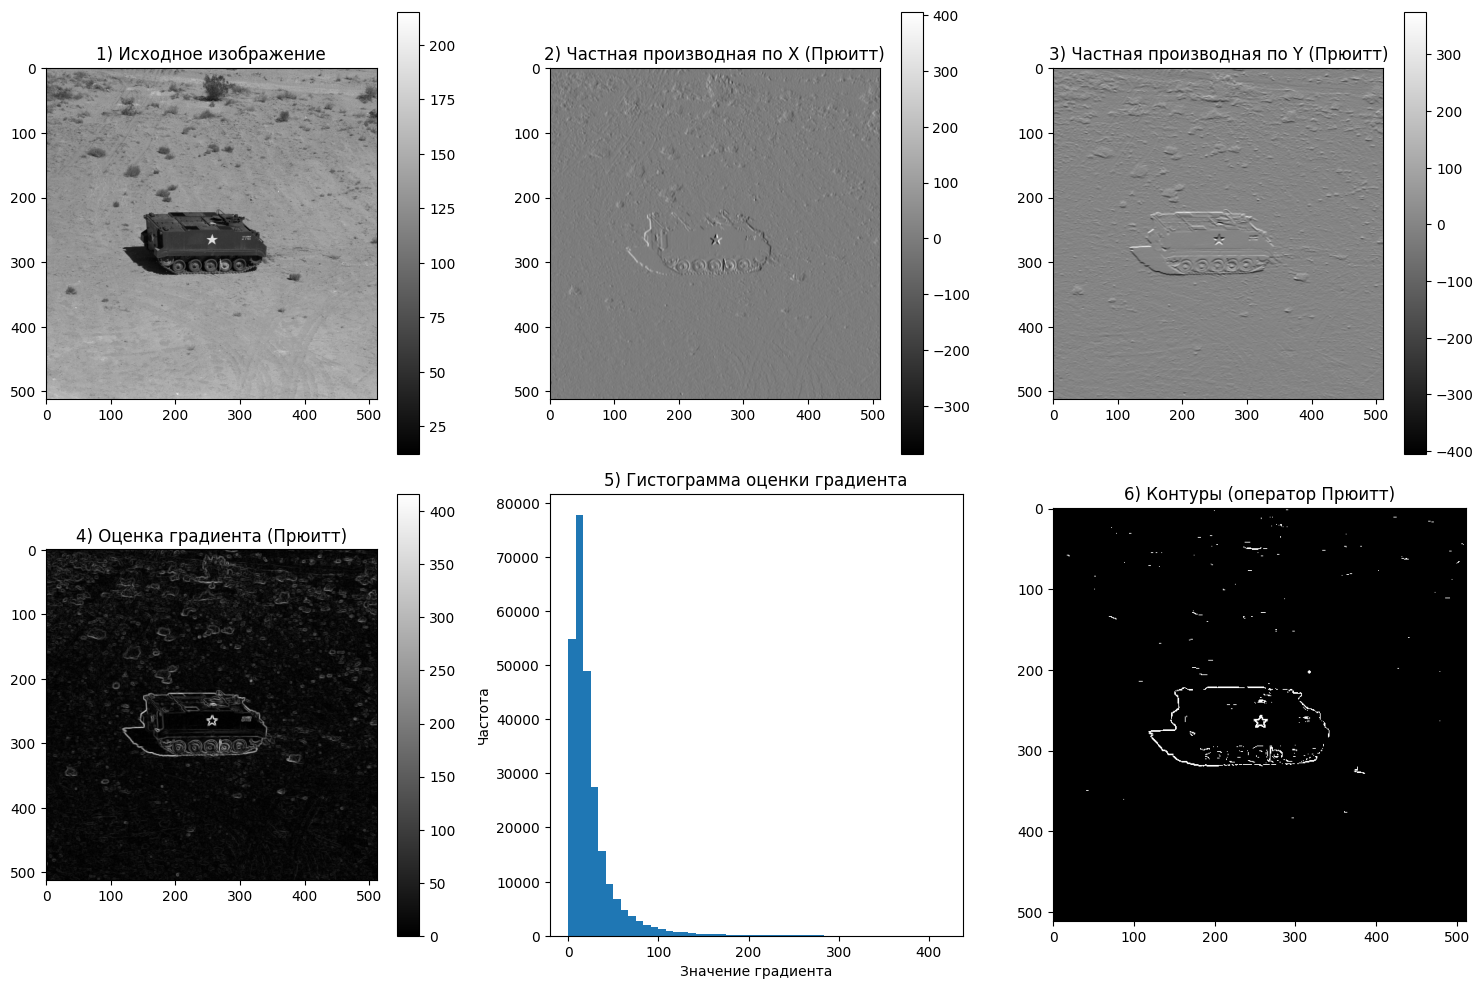

In [ ]:
# Применяем оператор Прюитта
prewitt_x, prewitt_y, prewitt_gradient = prewitt_operator_method(original_image)


for_neg = - prewitt_gradient.min()
# Визуализация результатов
plt.figure(figsize=(15, 10))

# 1) Исходное изображение
plt.subplot(2, 3, 1)
plt.imshow(original_image, cmap='gray')
plt.title('1) Исходное изображение')
plt.colorbar()

# 2) Частная производная по X (Прюитт)
plt.subplot(2, 3, 2)
plt.imshow(prewitt_x + for_neg, cmap='gray')
plt.title(f'2) Частная производная по X (Прюитт) + {for_neg}')
plt.colorbar()

# 3) Частная производная по Y (Прюитт)
plt.subplot(2, 3, 3)
plt.imshow(prewitt_y + for_neg, cmap='gray')
plt.title(f'3) Частная производная по Y (Прюитт) + {for_neg}')
plt.colorbar()

# 4) Оценка градиента (Прюитт)
plt.subplot(2, 3, 4)
plt.imshow(prewitt_gradient, cmap='gray')
plt.title('4) Оценка градиента (Прюитт)')
plt.colorbar()

# 5) Гистограмма оценки градиента
plt.subplot(2, 3, 5)
plt.hist(prewitt_gradient.flatten(), bins=50)
plt.title('5) Гистограмма оценки градиента')
plt.xlabel('Значение градиента')
plt.ylabel('Частота')

# 6) Контуры (бинарное изображение)
binary_prewitt = create_binary_image(prewitt_gradient, 0.4)
plt.subplot(2, 3, 6)
plt.imshow(binary_prewitt, cmap='gray')
plt.title('6) Контуры (оператор Прюитт)')

plt.tight_layout()
plt.show()

# 4. Метод **согласования** для лапласиана (маска (27))
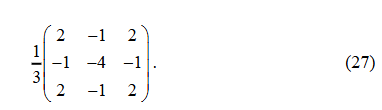

In [692]:
def matched_laplacian_method(image):
    """Метод согласования для лапласиана (маска 27)"""
    image_float = image.astype(np.float32)
    
    # Маска согласованного лапласиана
    matched_kernel = (1/3) * np.array([[2, -1, 2],
                               [-1, -4, -1],
                               [2, -1, 2]], dtype=np.float32)
    
    # Вычисляем согласованный лапласиан
    matched_laplacian = convolve2d(image_float, matched_kernel, mode='same', boundary='symm')
    
    return matched_laplacian


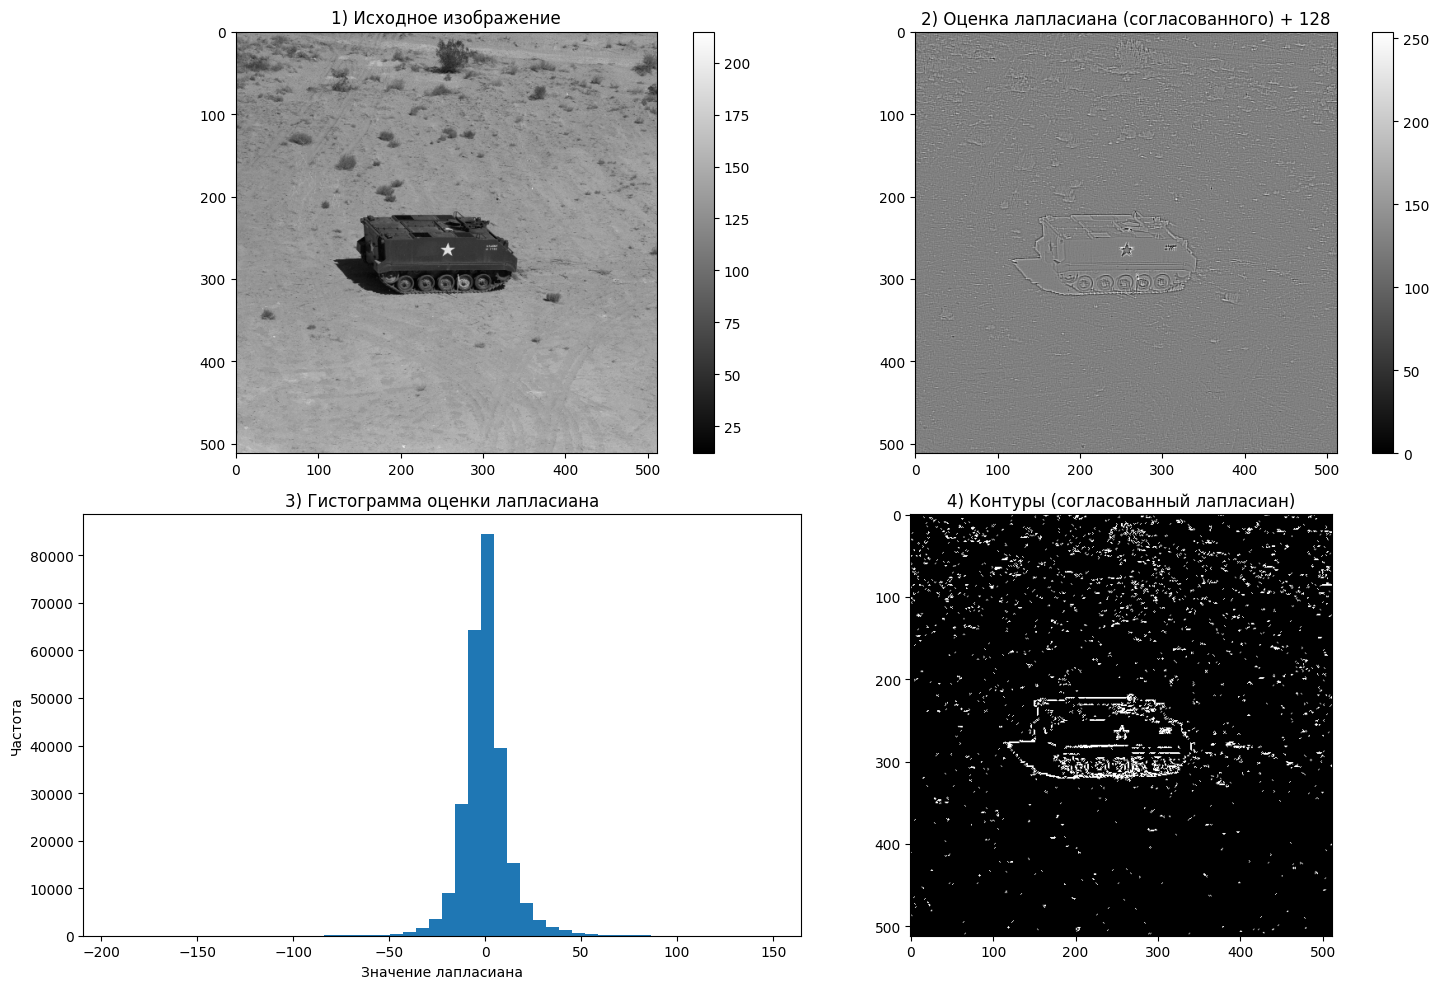

In [731]:
# Применяем метод согласованного лапласиана
matched_laplacian = matched_laplacian_method(original_image)

for_neg = 128
# Визуализация результатов
plt.figure(figsize=(15, 10))

# 1) Исходное изображение
plt.subplot(2, 2, 1)
plt.imshow(original_image, cmap='gray')
plt.title('1) Исходное изображение')
plt.colorbar()

# 2) Оценка лапласиана (согласованного)
plt.subplot(2, 2, 2)
plt.imshow((matched_laplacian + for_neg).astype(np.uint8), cmap='gray')
plt.title(f'2) Оценка лапласиана (согласованного) + {for_neg}')
plt.colorbar()

# 3) Гистограмма оценки лапласиана
plt.subplot(2, 2, 3)
plt.hist(matched_laplacian.flatten(), bins=50)
plt.title('3) Гистограмма оценки лапласиана')
plt.xlabel('Значение лапласиана')
plt.ylabel('Частота')

# 4) Контуры (бинарное изображение)
# Для согласованного лапласиана также ищем переходы через ноль
zero_crossings_matched = create_binary_image_laplac(matched_laplacian,1.9)

plt.subplot(2, 2, 4)
plt.imshow(zero_crossings_matched, cmap='gray')
plt.title('4) Контуры (согласованный лапласиан)')

plt.tight_layout()
plt.show()